<img src="../Pics/MLSb-T.png" width="160">
<br><br>
<center><u><H1>CIFAR10 with Inception module</H1></u></center>

In [1]:
import tensorflow as tf
from keras.backend.tensorflow_backend import set_session
config = tf.ConfigProto()
config.gpu_options.allow_growth = True
config.log_device_placement = True
sess = tf.Session(config=config)
set_session(sess) 

Using TensorFlow backend.


In [2]:
from keras.datasets import cifar10
from keras.utils import np_utils
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, concatenate
from keras.models import Model
from keras.optimizers import SGD, Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
%matplotlib inline

## Preprocessing and hyperparameters setup

In [3]:
batch_size = 32  # orig paper trained all networks with batch_size=128
epochs = 25
lrate = 0.01
decay = lrate/epochs
data_augmentation = True
num_classes = 10

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [5]:
y_train = np_utils.to_categorical(y_train, num_classes)
y_test = np_utils.to_categorical(y_test, num_classes)

## Create the inception module

In [6]:
input_img = Input(shape=(32,32,3))

In [7]:
group_1 = Conv2D(64, (1,1), padding='same', activation='relu')(input_img)
group_1 = Conv2D(64, (3,3), padding='same', activation='relu')(group_1)
group_2 = Conv2D(64, (1,1), padding='same', activation='relu')(input_img)
group_2 = Conv2D(64, (5,5), padding='same', activation='relu')(group_2)
group_3 = MaxPooling2D((3,3), strides=(1,1), padding='same')(input_img)
group_3 = Conv2D(64, (1,1), padding='same', activation='relu')(group_3)

Instructions for updating:
Colocations handled automatically by placer.


In [8]:
output = concatenate([group_1, group_2, group_3], axis=3)

In [9]:
output = Flatten()(output)
out = Dense(10, activation='softmax')(output)

In [10]:
model = Model(inputs = input_img, outputs= out)

In [11]:
model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 32, 32, 3)    0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 32, 32, 64)   256         input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_3 (Conv2D)               (None, 32, 32, 64)   256         input_1[0][0]                    
__________________________________________________________________________________________________
max_pooling2d_1 (MaxPooling2D)  (None, 32, 32, 3)    0           input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_2 (

## Setting up the training

In [12]:
sgd = SGD(lr=lrate, momentum=0.9, decay=decay, nesterov=False)

In [13]:
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [14]:
filepath = "inception-model.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True)

In [15]:
early = EarlyStopping(monitor="val_loss", 
                      mode="min", 
                      patience=4, restore_best_weights=True)
callbacks = [checkpoint, early]

In [16]:
if not data_augmentation:
    print('Not using data augmentation.')
    history = model.fit(X_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              validation_data=(X_test, y_test),
              callbacks=callbacks)
else:
    print('Using real-time data augmentation.')
    # This will do preprocessing and realtime data augmentation:
    datagen = ImageDataGenerator(
        # set input mean to 0 over the dataset
        featurewise_center=False,
        # set each sample mean to 0
        samplewise_center=False,
        # divide inputs by std of dataset
        featurewise_std_normalization=False,
        # divide each input by its std
        samplewise_std_normalization=False,
        # apply ZCA whitening
        zca_whitening=False,
        # epsilon for ZCA whitening
        zca_epsilon=1e-06,
        # randomly rotate images in the range (deg 0 to 180)
        rotation_range=30,
        # randomly shift images horizontally
        width_shift_range=0.1,
        # randomly shift images vertically
        height_shift_range=0.1,
        # set range for random shear
        shear_range=0.2,
        # set range for random zoom
        zoom_range=0.2,
        # set range for random channel shifts
        channel_shift_range=0.,
        # set mode for filling points outside the input boundaries
        fill_mode='nearest',
        # value used for fill_mode = "constant"
        cval=0.,
        # randomly flip images
        horizontal_flip=True,
        # randomly flip images
        vertical_flip=False,
        # set rescaling factor (applied before any other transformation)
        rescale=None,
        # set function that will be applied on each input
        preprocessing_function=None,
        # image data format, either "channels_first" or "channels_last"
        data_format=None,
        # fraction of images reserved for validation (strictly between 0 and 1)
        validation_split=0.0)

Using real-time data augmentation.


## Train model

In [17]:
datagen.fit(X_train)
X_train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)

In [18]:
print(f"Number of samples:{X_train_generator.n}")
print(f"Batch size:{X_train_generator.batch_size}")
step_size_train = X_train_generator.n // X_train_generator.batch_size
print(f"Step size train: {step_size_train}")

Number of samples:50000
Batch size:32
Step size train: 1562


In [19]:
history = model.fit_generator(X_train_generator,
                        validation_data=(X_test, y_test),
                        epochs=epochs, verbose=1,
                        steps_per_epoch=step_size_train,
                        callbacks=callbacks)

Instructions for updating:
Use tf.cast instead.
Epoch 1/25
1562/1562 [==============================] - 32s 20ms/step - loss: 1.7261 - acc: 0.3806 - val_loss: 1.4108 - val_acc: 0.4956

Epoch 00001: val_acc improved from -inf to 0.49560, saving model to inception-model.h5
Epoch 2/25
1562/1562 [==============================] - 28s 18ms/step - loss: 1.5048 - acc: 0.4636 - val_loss: 1.3115 - val_acc: 0.5350

Epoch 00002: val_acc improved from 0.49560 to 0.53500, saving model to inception-model.h5
Epoch 3/25
1562/1562 [==============================] - 28s 18ms/step - loss: 1.4172 - acc: 0.4954 - val_loss: 1.2525 - val_acc: 0.5637

Epoch 00003: val_acc improved from 0.53500 to 0.56370, saving model to inception-model.h5
Epoch 4/25
1562/1562 [==============================] - 28s 18ms/step - loss: 1.3657 - acc: 0.5130 - val_loss: 1.2134 - val_acc: 0.5753

Epoch 00004: val_acc improved from 0.56370 to 0.57530, saving model to inception-model.h5
Epoch 5/25
1562/1562 [=========================

## Visualizing metrics

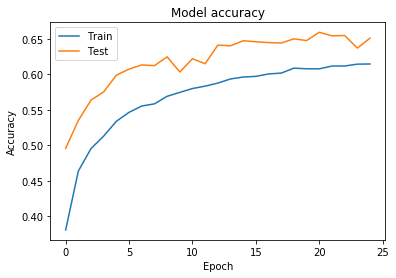

In [20]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

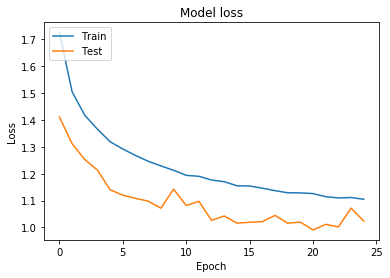

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

## Reference:
- https://keras.io/api/applications/